<h1 style="color:darkcyan;">PROJECT TITLE : CUSTOMER SERVICE REQUEST ANALYSIS USING PYTHON</h1>

<h1 style="color:red;">PROBLEM STATEMENT</h1>

The objective of this project is to analyze New York City 311 service request data using Python. The main goal is to understand complaint patterns, perform data cleaning, handle missing values, visualize major complaint types, analyze response time, and apply statistical testing to determine whether complaint resolution times differ significantly across complaint types.

This project helps in understanding real-world customer service request handling and improves decision-making through data analysis and visualization.

<h1 style="color:red;">OBJECTIVES</h1>

##### -Import and understand the dataset
##### -Identify and treat missing values
##### -Analyze complaint patterns across cities
##### -Create visualizations for complaint distribution
##### -Calculate request closing time
##### -Analyze average response time for complaints
##### -Perform Kruskal-Wallis statistical test
##### -Present final observations and insights

## 1.UNDERSTAND THE DATASET

## LIBRARIES USED

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1 import dataset

In [2]:
df = pd.read_csv("311_Service_Requests_from_2010_to_Present.csv",
                low_memory = False)

### 1.2 Visualize the dataset

In [3]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [4]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [5]:
df.shape

(364558, 53)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unique Key                      364558 non-null  int64  
 1   Created Date                    364558 non-null  object 
 2   Closed Date                     362177 non-null  object 
 3   Agency                          364558 non-null  object 
 4   Agency Name                     364558 non-null  object 
 5   Complaint Type                  364558 non-null  object 
 6   Descriptor                      358057 non-null  object 
 7   Location Type                   364425 non-null  object 
 8   Incident Zip                    361560 non-null  float64
 9   Incident Address                312859 non-null  object 
 10  Street Name                     312859 non-null  object 
 11  Cross Street 1                  307370 non-null  object 
 12  Cross Street 2  

In [7]:
df.isnull().sum()

Unique Key                             0
Created Date                           0
Closed Date                         2381
Agency                                 0
Agency Name                            0
Complaint Type                         0
Descriptor                          6501
Location Type                        133
Incident Zip                        2998
Incident Address                   51699
Street Name                        51699
Cross Street 1                     57188
Cross Street 2                     57805
Intersection Street 1             313438
Intersection Street 2             314046
Address Type                        3252
City                                2997
Landmark                          364183
Facility Type                       2389
Status                                 0
Due Date                               3
Resolution Description                 0
Resolution Action Updated Date      2402
Community Board                        0
Borough         

## 2.Exploratory Data Analysis (EDA)

### 2.1 Frequency plot of null values

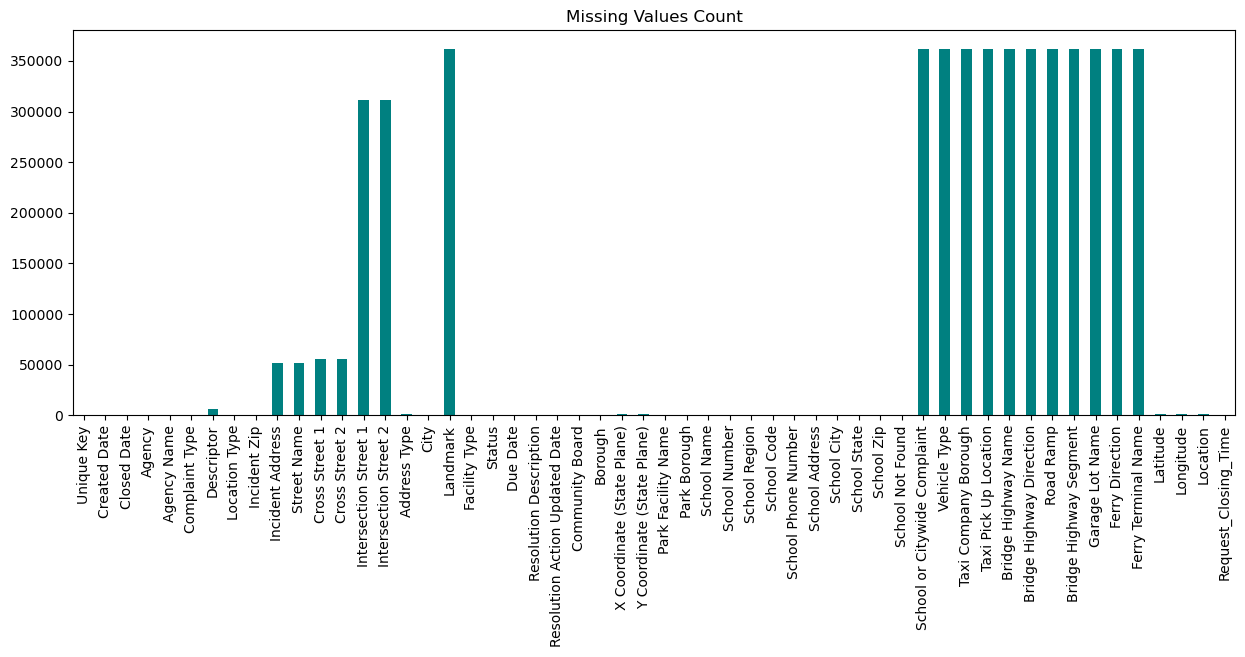

In [37]:
df.isnull().sum().plot(kind='bar', figsize=(15,5),color='teal')
plt.title("Missing Values Count")
plt.show()

### Missing Value Treatment

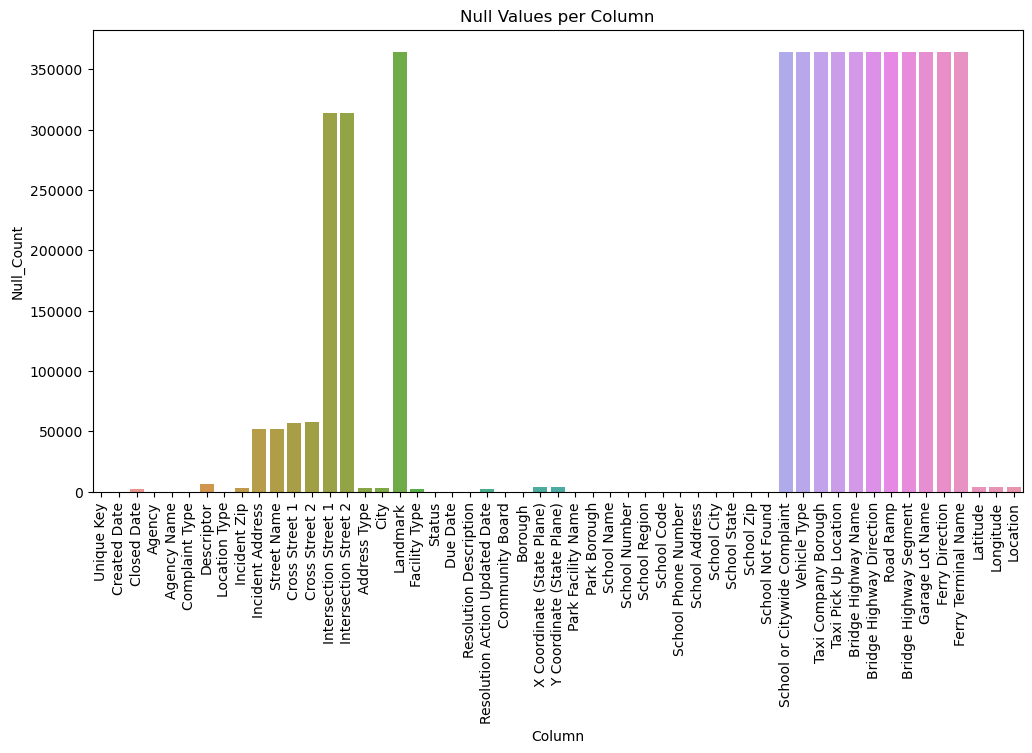

In [9]:
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ['Column', 'Null_Count']

plt.figure(figsize=(12,6))
sns.barplot(x='Column', y='Null_Count', data=null_counts)
plt.title("Null Values per Column")
plt.xticks(rotation=90)
plt.show()

In [10]:
df = df[df['Closed Date'].notnull()]

#2.3 Date Analysis

In [15]:
df['Created Date'] = pd.to_datetime(df['Created Date'],format='%m/%d/%Y %I:%M:%S %p')

df['Closed Date'] = pd.to_datetime(df['Closed Date'],format='%m/%d/%Y %I:%M:%S %p')

In [16]:
df = df[df['Closed Date'] >= df['Created Date']]

#2.3.1 Time Elapsed

In [17]:
df['Request_Closing_Time'] = df['Closed Date'] - df['Created Date']

#2.3.2 convert to seconds

In [18]:
df['Request_Closing_Time'] = df['Request_Closing_Time'].dt.total_seconds()

#2.3.3 Descriptive stats

In [19]:
df['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

 #2.3.4 null values in important columns

In [20]:
df[['Complaint Type', 'City']].isnull().sum()

Complaint Type      0
City              674
dtype: int64

#2.3.5 fill missing values

In [21]:
df['City'].fillna("Unknown City", inplace=True)
df['Complaint Type'].fillna("Unknown", inplace=True)

#2.3.6 Complaints per City

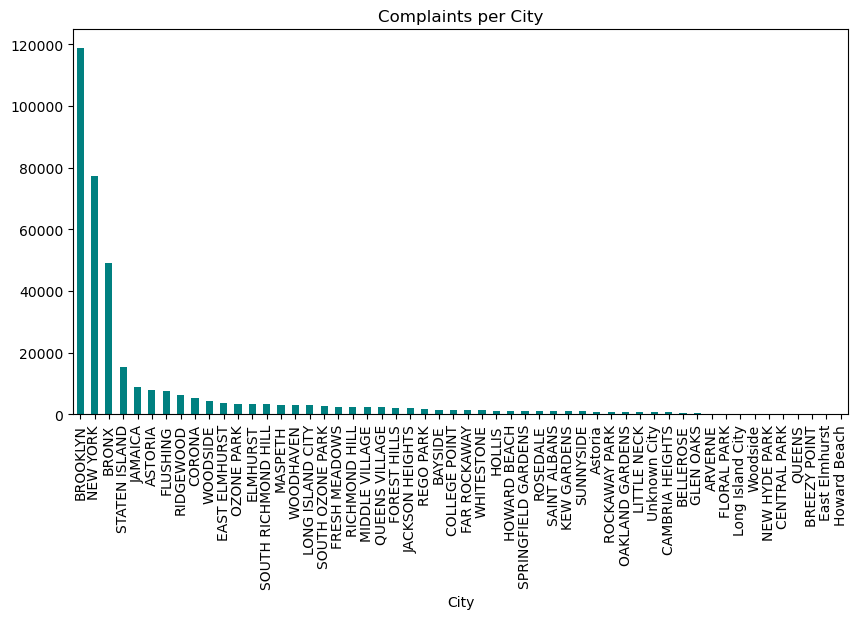

In [39]:
df['City'].value_counts().plot(kind='bar', figsize=(10,5),color='teal')
plt.title("Complaints per City")
plt.show()

#2.3..7Brooklyn Visualization

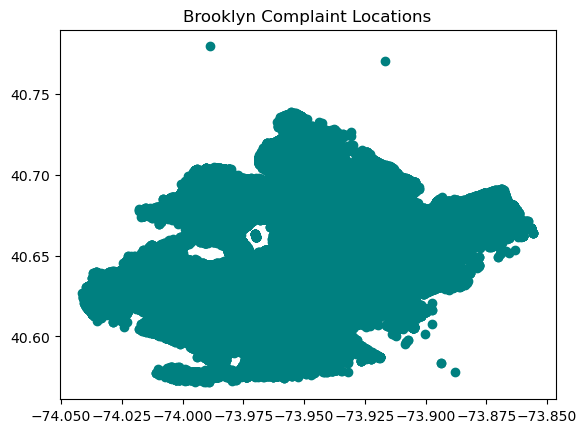

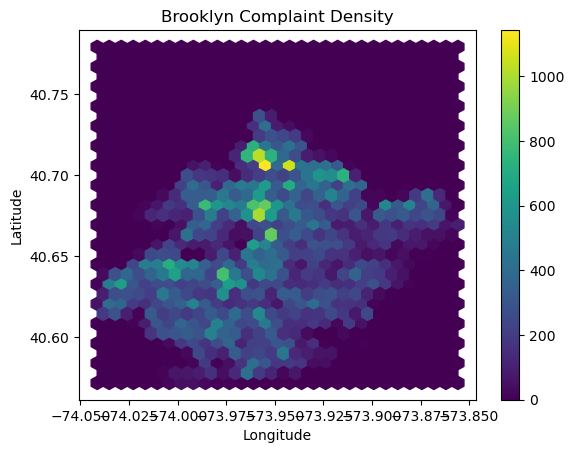

In [43]:
brooklyn = df[df['City'] == 'BROOKLYN']

# Scatter Plot
plt.scatter(brooklyn['Longitude'], brooklyn['Latitude'],color='teal')
plt.title("Brooklyn Complaint Locations")
plt.show()

# Hexbin Plot
brooklyn.plot.hexbin(x='Longitude', y='Latitude', gridsize=30, cmap='viridis')
plt.title("Brooklyn Complaint Density")
plt.show()

## 3. Major Types of Complaints

3.1 Complaint types Bar Chart 

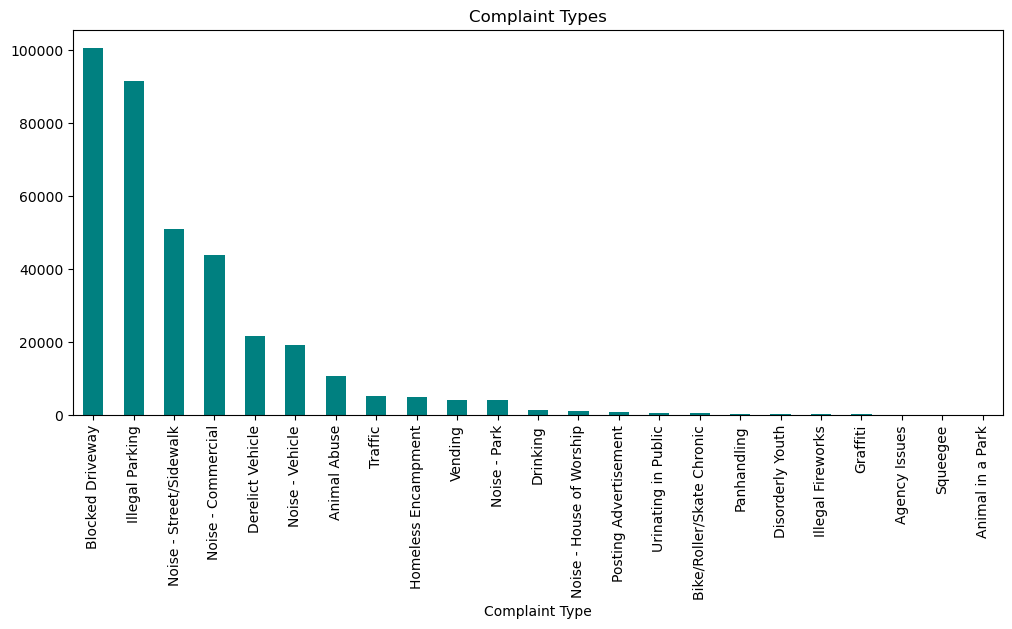

In [44]:
df['Complaint Type'].value_counts().plot(kind='bar', figsize=(12,5),color='teal')
plt.title("Complaint Types")
plt.show()

3.2 Complaints in New York City

In [25]:
nyc = df[df['City'] == 'NEW YORK']
nyc['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk      22245
Noise - Commercial           18686
Illegal Parking              14549
Noise - Vehicle               6294
Homeless Encampment           3060
Blocked Driveway              2705
Vending                       2638
Animal Abuse                  1941
Traffic                       1769
Noise - Park                  1243
Derelict Vehicle               695
Drinking                       321
Urinating in Public            264
Bike/Roller/Skate Chronic      254
Noise - House of Worship       222
Panhandling                    206
Disorderly Youth                81
Posting Advertisement           49
Illegal Fireworks               38
Graffiti                        25
Squeegee                         4
Name: count, dtype: int64

3.3 Top 10 Complaints

In [26]:
df['Complaint Type'].value_counts().head(10)

Complaint Type
Blocked Driveway           100624
Illegal Parking             91716
Noise - Street/Sidewalk     51139
Noise - Commercial          43751
Derelict Vehicle            21518
Noise - Vehicle             19301
Animal Abuse                10530
Traffic                      5196
Homeless Encampment          4879
Vending                      4185
Name: count, dtype: int64

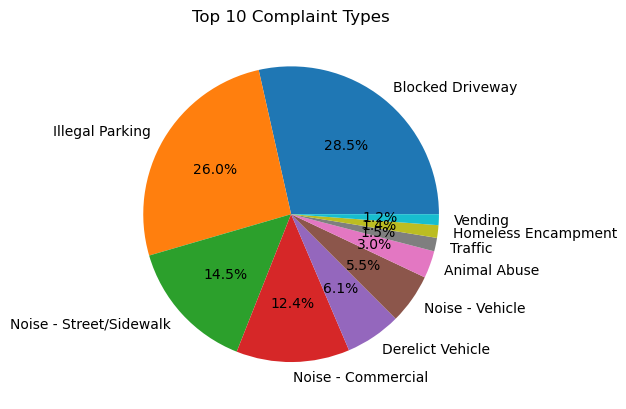

In [27]:
top5 = df['Complaint Type'].value_counts().head(10)

top5.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 10 Complaint Types")
plt.ylabel('')
plt.show()

3.4 Complaints by City

In [28]:
pd.crosstab(df['City'], df['Complaint Type'])

Complaint Type,Agency Issues,Animal Abuse,Animal in a Park,Bike/Roller/Skate Chronic,Blocked Driveway,Derelict Vehicle,Disorderly Youth,Drinking,Graffiti,Homeless Encampment,...,Noise - House of Worship,Noise - Park,Noise - Street/Sidewalk,Noise - Vehicle,Panhandling,Posting Advertisement,Squeegee,Traffic,Urinating in Public,Vending
City,,,,,,,,,,,,,,,,,,,,,
ARVERNE,0,46,0,0,50,32,2,1,1,4,...,14,2,29,10,1,0,0,1,1,1
ASTORIA,0,170,0,16,3436,426,5,43,4,32,...,21,64,409,236,2,3,0,60,10,57
Astoria,0,0,0,0,159,14,0,0,0,0,...,0,0,145,0,0,0,0,0,0,0
BAYSIDE,0,53,0,0,514,231,2,1,3,2,...,3,4,17,24,0,0,0,9,0,2
BELLEROSE,0,15,0,1,138,120,2,1,0,1,...,1,1,13,11,1,1,0,9,1,0
BREEZY POINT,0,2,0,0,3,3,0,1,0,0,...,0,0,1,1,0,0,0,0,0,0
BRONX,0,1971,0,22,17062,2402,66,206,15,275,...,90,548,9144,3556,20,18,0,427,54,433
BROOKLYN,0,3191,0,124,36445,6257,79,291,60,948,...,389,1575,13982,5965,49,58,0,1258,155,575
CAMBRIA HEIGHTS,0,15,0,0,177,148,0,0,0,6,...,2,0,29,100,0,0,0,7,0,0


3.5 Create df_new

In [29]:
df_new = pd.crosstab(df['Complaint Type'], df['City'])
df_new.head()

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,Unknown City,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Agency Issues,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
Animal Abuse,46,170,0,53,15,2,1971,3191,15,0,...,74,40,42,786,40,1,43,57,111,0
Animal in a Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bike/Roller/Skate Chronic,0,16,0,0,1,0,22,124,0,0,...,1,1,0,10,2,2,4,2,5,0
Blocked Driveway,50,3436,159,514,138,3,17062,36445,177,0,...,1202,1946,330,2845,278,86,279,1363,2038,27


## 4.Visualization

4.1 Combined Chart

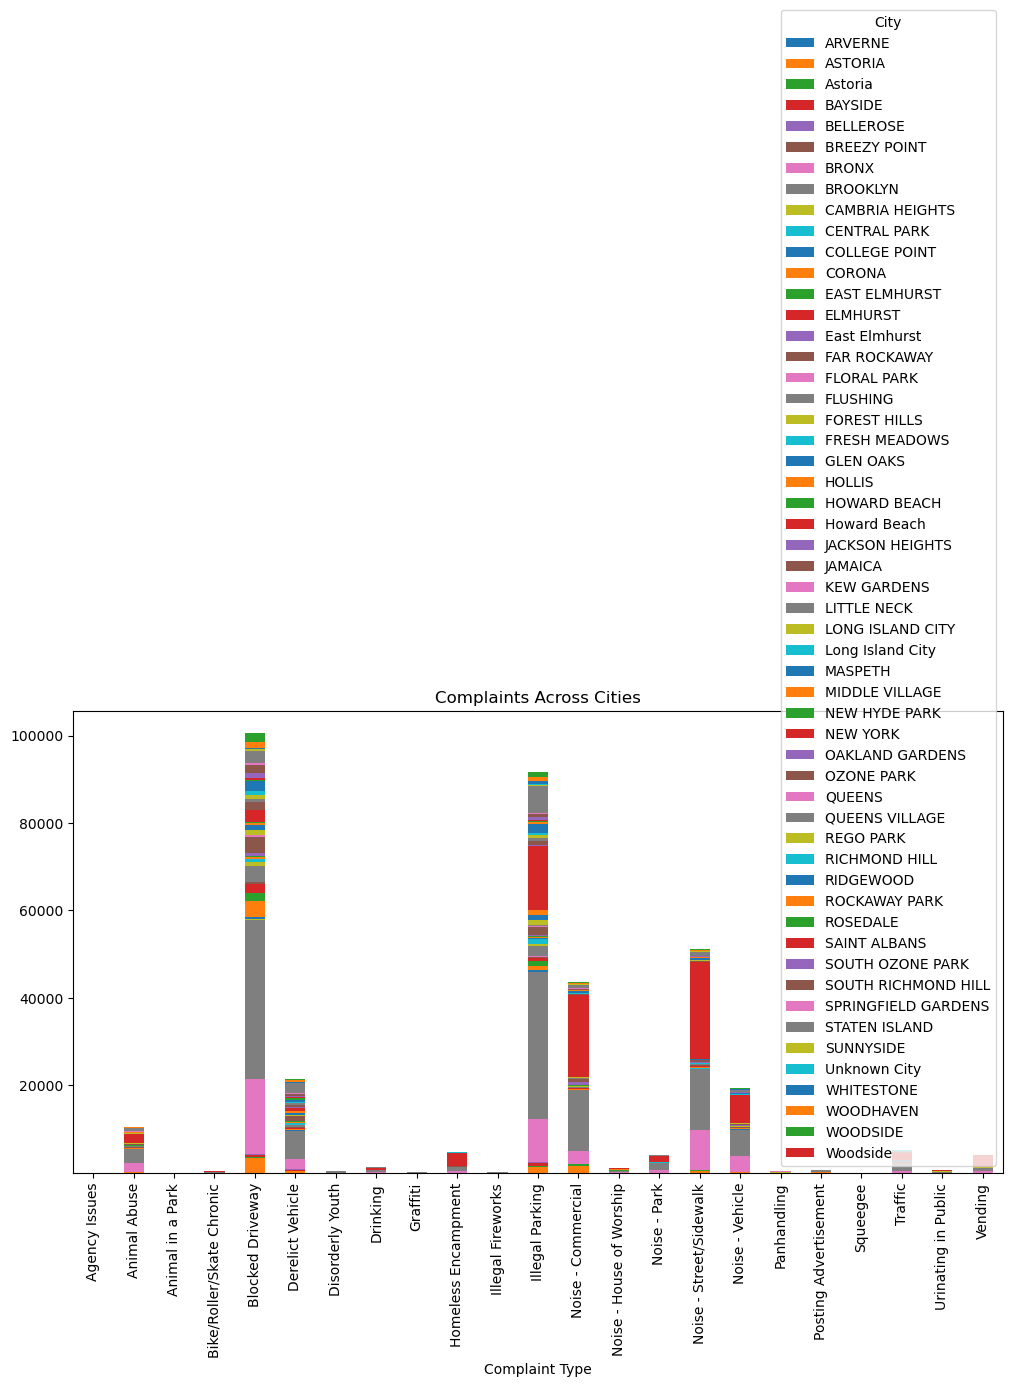

In [30]:
df_new.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Complaints Across Cities")
plt.show()

4.2 Sort by Average Response Time

In [31]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [32]:
avg_time = df.groupby(['City','Complaint Type'])['Request_Closing_Time'].mean()
avg_time = avg_time.sort_values()
avg_time.head()

City           Complaint Type           
ARVERNE        Drinking                      859.0
RIDGEWOOD      Posting Advertisement         895.0
EAST ELMHURST  Bike/Roller/Skate Chronic     908.0
OZONE PARK     Illegal Fireworks            1191.0
QUEENS         Urinating in Public          1226.0
Name: Request_Closing_Time, dtype: float64

## 5 Average Response Time Analysis

5.1 Visualization

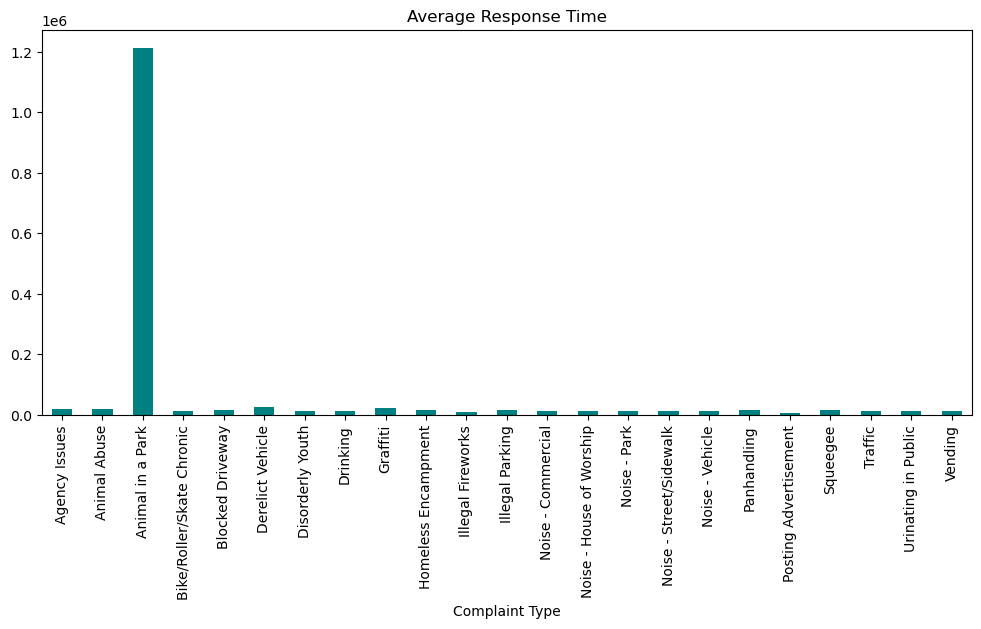

In [45]:
df.groupby('Complaint Type')['Request_Closing_Time'].mean().plot(kind='bar', figsize=(12,5),color='teal')
plt.title("Average Response Time")
plt.show()

## 7. Kruskal-Wallis Test

In [34]:
from scipy.stats import kruskal

groups = [group['Request_Closing_Time'].values 
          for name, group in df.groupby('Complaint Type')]

stat, p = kruskal(*groups)

print("P-value:", p)

P-value: 0.0


<h1 style="color:darkcyan;">FINAL OUTCOME</h1>

This project helps in understanding service request behavior and operational efficiency using Python-based data analysis.

It supports better decision-making by identifying high-priority complaint areas, delayed services, and city-wise performance gaps.

The final insights can help improve customer satisfaction, faster complaint resolution, and better public service management.